In [75]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
start=0
end=10
step_size=0.3
X=torch.arange(start,end,step_size).unsqueeze(dim=1)
weight=0.35
bias=torch.randn_like(X)*0.1
y=weight*X+bias
train_split=int(len(X)*0.8)


In [76]:
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
X_train,y_train

(tensor([[0.0000],
         [0.3000],
         [0.6000],
         [0.9000],
         [1.2000],
         [1.5000],
         [1.8000],
         [2.1000],
         [2.4000],
         [2.7000],
         [3.0000],
         [3.3000],
         [3.6000],
         [3.9000],
         [4.2000],
         [4.5000],
         [4.8000],
         [5.1000],
         [5.4000],
         [5.7000],
         [6.0000],
         [6.3000],
         [6.6000],
         [6.9000],
         [7.2000],
         [7.5000],
         [7.8000]]),
 tensor([[0.1927],
         [0.2537],
         [0.3001],
         [0.1044],
         [0.4878],
         [0.4015],
         [0.6257],
         [0.5745],
         [0.7648],
         [1.1099],
         [1.0108],
         [1.0146],
         [1.1872],
         [1.3091],
         [1.3931],
         [1.6512],
         [1.8442],
         [1.7690],
         [1.8677],
         [2.1667],
         [2.1319],
         [2.1625],
         [2.3406],
         [2.3375],
         [2.5235],
         [

In [77]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # self.weight=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))
        # self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))
        self.linear_layer=nn.Linear(in_features=1,out_features=1)
    def forward(self,x:torch.tensor):
        # return self.weight*x+self.bias
        return self.linear_layer(x)

In [78]:
model=LinearRegressionModel()
torch.manual_seed(42)
list(model.parameters())

[Parameter containing:
 tensor([[-0.9899]], requires_grad=True),
 Parameter containing:
 tensor([-0.3864], requires_grad=True)]

In [79]:
def plots(train_data=X_train,train_label=y_train,
          test_data=X_test,test_label=y_test,
          predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_label,c="b")
    plt.scatter(test_data,test_label,c="r")

    if predictions is not None:
        plt.scatter(test_data,predictions,c="g")
    

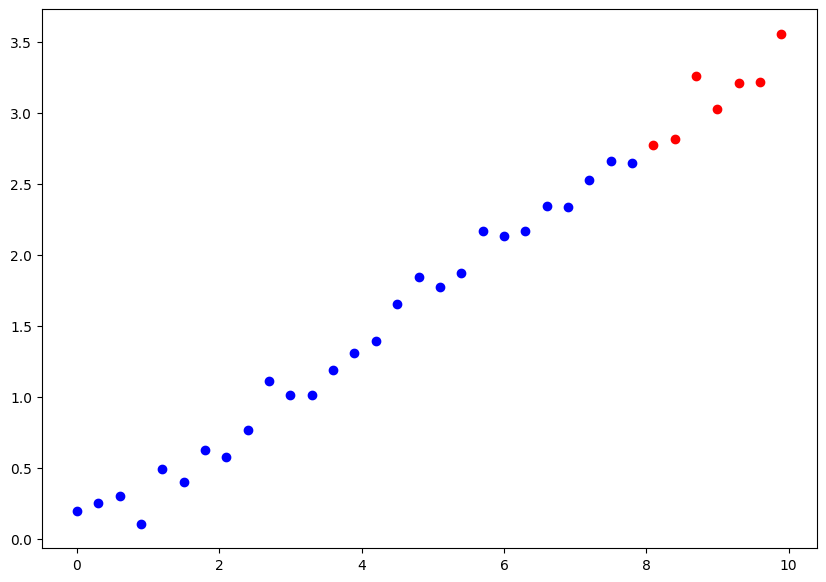

In [80]:
plots()

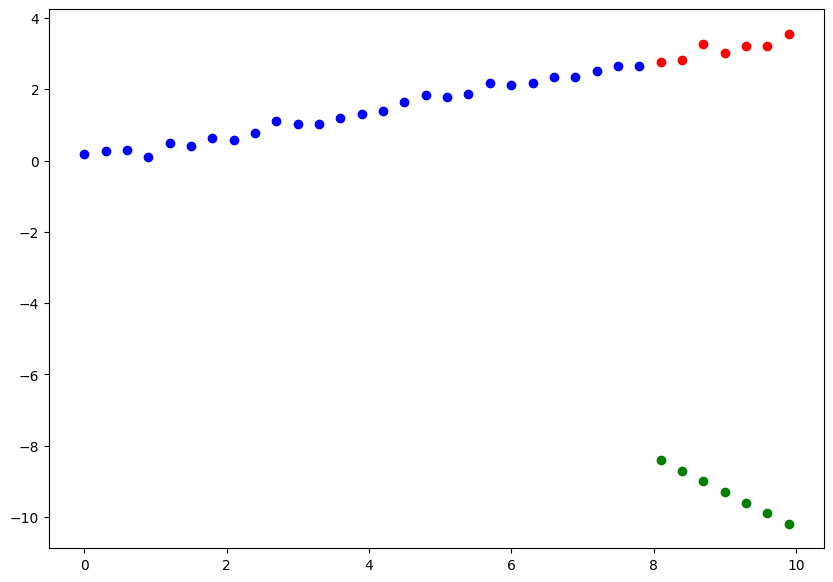

In [81]:
with torch.inference_mode():
    y_preds=model(X_test)
plots(predictions=y_preds)

In [82]:
loss_fn=nn.L1Loss()
loss_fn

L1Loss()

In [83]:
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.1)

In [84]:
epochs=200
train_loss_values = []
test_loss_values = []
epoch_count = []
for epoch in range(epochs):
    model.train()
    y_pred_train=model(X_train)
    loss=loss_fn(y_pred_train,y_train)
    optimizer.zero_grad()
    loss.backward()
    # print(f"loss before optimizer step {loss}")
    optimizer.step()

    #for test loss loop
    model.eval()
    with torch.no_grad():
         y_pred_test=model(X_test)
         loss_test=loss_fn(y_pred_test,y_test)
         # print(f"loss after optimizer step {loss_test}")
    print(model.state_dict())
    if epoch%10==0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(loss_test.detach().numpy())
        print(f"loss before optimizer step {loss}")
        print(f"loss after optimizer step {loss_test}")
        print(epoch)

OrderedDict([('linear_layer.weight', tensor([[-0.5999]])), ('linear_layer.bias', tensor([-0.2864]))])
loss before optimizer step 5.61085844039917
loss after optimizer step 8.80700969696045
0
OrderedDict([('linear_layer.weight', tensor([[-0.2099]])), ('linear_layer.bias', tensor([-0.1864]))])
OrderedDict([('linear_layer.weight', tensor([[0.1801]])), ('linear_layer.bias', tensor([-0.0864]))])
OrderedDict([('linear_layer.weight', tensor([[0.5701]])), ('linear_layer.bias', tensor([0.0136]))])
OrderedDict([('linear_layer.weight', tensor([[0.1823]])), ('linear_layer.bias', tensor([-0.0715]))])
OrderedDict([('linear_layer.weight', tensor([[0.5723]])), ('linear_layer.bias', tensor([0.0285]))])
OrderedDict([('linear_layer.weight', tensor([[0.1845]])), ('linear_layer.bias', tensor([-0.0567]))])
OrderedDict([('linear_layer.weight', tensor([[0.5679]])), ('linear_layer.bias', tensor([0.0359]))])
OrderedDict([('linear_layer.weight', tensor([[0.1801]])), ('linear_layer.bias', tensor([-0.0493]))])
Ord

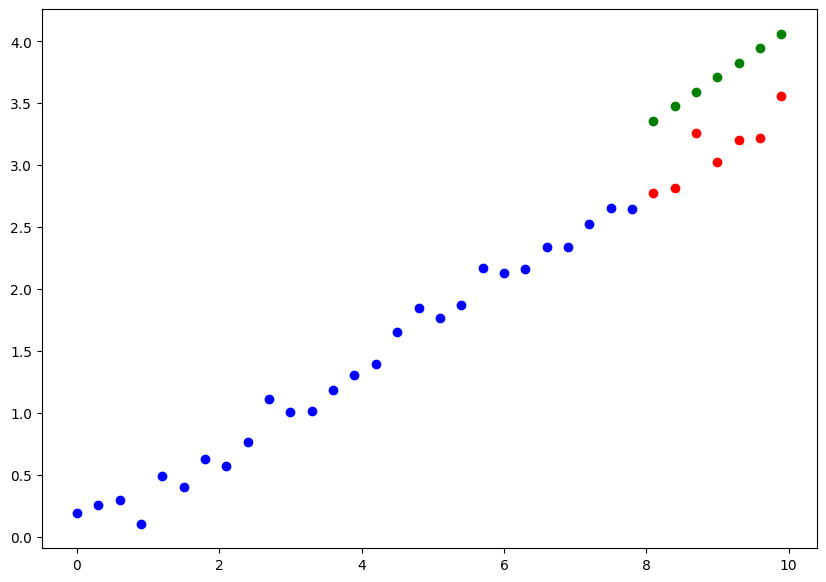

In [85]:
with torch.inference_mode():
    y_pred_la=model(X_test)
plots(predictions=y_pred_la)

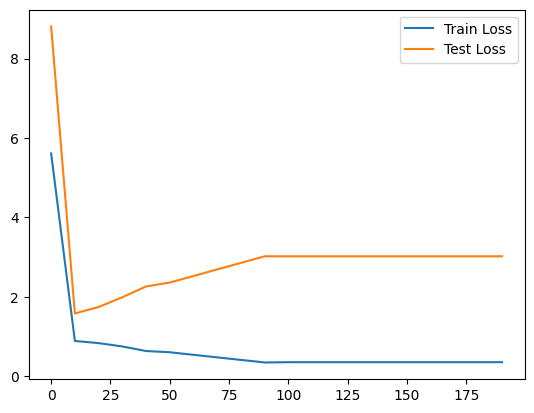

In [86]:
import matplotlib.pyplot as plt

plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.legend()
plt.show()